# Lab 4, Day 1 — Regression on California Housing

Build an MLP regressor in PyTorch, then compare it head-to-head against your own Lab 2
NumPy gradient descent code on the exact same data. See `Lab4_Day1_Instructions.md`
for the full walkthrough.

This notebook is just a shell: it gives you a place to call and plot your functions,
but the loading, model, training loop, and comparison are yours to write.

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device

device(type='mps')

## Step 1: Load and preprocess (`stage_a_regression.py`)

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
california_housing = fetch_california_housing(as_frame = True)
print(california_housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [4]:
california_housing.frame.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
# TODO: load California Housing, split train/test, fit_transform the scaler on
# train only, transform test, reshape targets to (n, 1)

torch.manual_seed(0)
np.random.seed(0)

data = fetch_california_housing()
x_train, x_test, \
y_train, y_test = train_test_split(
                                    data.data, 
                                    data.target,
                                    test_size=0.2,
                                    random_state=0
                                )

scalar = StandardScaler()

x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

x_train = torch.tensor(x_train, dtype = torch.float32)
x_test = torch.tensor(x_test, dtype = torch.float32)
y_train = torch.tensor(y_train, dtype = torch.float32).reshape(-1, 1)
y_test = torch.tensor(y_test, dtype = torch.float32).reshape(-1, 1)

'''
    IMPORTANT READ THIS:
    
    If you leave y_train as shape (n,) while your model outputs shape (n, 1), 
    MSELoss will silently broadcast them into an (n, n) matrix instead of erroring. 
    The loss still computes, still decreases, and is completely meaningless. 
    This is the easiest bug in the whole lab to miss, 
    because nothing crashes — check your shapes explicitly.
''';


## Step 2-3: Model, loss, optimizer, training loop

In [ ]:
# TODO: build_mlp from train.py (or write it directly), train with train_full_batch,
# store loss.item() each epoch - not the tensor itself

def build_mlp(layers, act = 'relu'):
    in_dim, hidden, out_dim = layers[0], layers[1:-1], layers[-1]

    class MLP(nn.Module):
        def __init__(self, in_dim, hidden, out_dim, activation = act):
            super().__init__()
            self.fc_first = nn.Linear(in_dim, hidden[0])
            self.hidden = nn.ModuleList(
                                        [nn.Linear(hidden[i], hidden[i+1]) for i in range(len(hidden) - 1)]
                                    )
            self.fc_last = nn.Linear(hidden[-1], out_dim)

            self.relu = nn.ReLU()
            self.gelu = nn.GELU()
            self.swish = nn.SiLU()
            self.tanh = nn.Tanh()
            self.sign = torch.sign

            self.activation = self.activation_selector(activation.lower())


        def activation_selector(self, activation):
            if activation == 'relu':
                return self.relu
            elif activation == 'gelu':
                return self.gelu
            elif activation == 'swish':
                return self.swish
            elif activation == 'tanh':
                return self.tanh
            else:
                return self.sign
            

        def forward(self, x):
            x = self.fc_first(x)
            x = self.activation(x)
            for fc_hidden in self.hidden:
                x = fc_hidden(x)
                x = self.activation(x)
            x = self.fc_last(x)
            return x

    return MLP(in_dim, hidden, out_dim)

EPOCH = 100
BATCH_SIZE = 32
CHECKPOINT = 10

train_data = TensorDataset(x_train, y_train)

train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size

train_data, val_data = random_split(
    train_data,
    [train_size, val_size]
)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

model = build_mlp([8, 32, 1])
model = model.to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)






def training(train_loader, val_loader, epoch, optimizer, loss, checkpoints, save_checkpoints_weights = False)

epoch_history = []

train_loss_history = []
train_acc_history = []

val_loss_history = []
val_acc_history = []

run_loop = tqdm(range(epoch))
for epoch in run_loop:
    epoch_history.append(epoch)


    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        predictions = model(x_batch)
        train_batch_loss = loss_fn(predictions, y_batch)

        train_loss+=train_batch_loss

        train_correct += (predictions.argmax(dim=1) == y_batch).sum().item()
        train_total += 1

        optimizer.zero_grad()
        train_batch_loss.backward()
        optimizer.step()

    train_loss = train_loss / train_total
    train_loss_history.append(train_loss)
    # train_acc = train_correct / train_total
    # train_acc_history.append(train_acc)

    model.eval()


    val_epoch_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        val_loss = 0

        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(x_batch)
            val_batch_loss = loss_fn(predictions, y_batch)

            val_loss += val_batch_loss
            val_correct += (predictions.argmax(dim=1) == y_batch).sum().item()
            val_total += 1

        val_loss = val_loss / val_total
        val_loss_history.append(val_loss)
        # val_acc = val_correct / val_total
        # val_acc_history.append(val_acc)

    # tqdm.write(f"Epoch {epoch}: train loss = {train_loss:.4f}, val loss = {val_loss:.4f}")
    pbar.set_postfix(
    loss=0.123,
    accuracy="95%",
    status="training"
)

    if epoch%CHECKPOINT == 0:
        torch.save(model.state_dict(), 'model.pt')


NameError: name 'TensorDataset' is not defined

## Step 4: Evaluate and plot

/var/folders/q1/8yqywfr94cb72vqk8zjyyqnm0000gn/T/ipykernel_30800/2981610137.py:3: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  plt.plot(torch.tensor(train_loss_history).to('cpu'), label='train')


<function matplotlib.pyplot.show(close=None, block=None)>

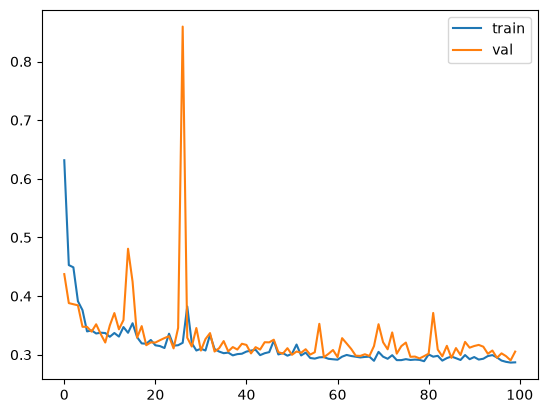

In [15]:
# TODO: model.eval() + torch.no_grad() to get test MSE; plot the training loss curve

plt.plot(torch.tensor(train_loss_history).to('cpu'), label='train')
plt.plot(torch.tensor(val_loss_history).to('cpu'), label='val')
plt.legend()
plt.show

## Step 5: Compare against your Lab 2 NumPy code

In [ ]:
# TODO: fit a linear model on the same preprocessed data using your own hand-derived
# gradient descent, compare test MSE against the MLP, plot both curves side by side


### Written prompt

> **Your MLP barely beats the linear model, and might lose to it. What would have to be
> true about this data for the MLP to win decisively — and what does that tell you about
> when a neural network is the right tool?**

(Replace this cell's text with your answer in a short paragraph.)

---
**Before you close this notebook today:** save your trained model
(`torch.save(model.state_dict(), "stage_a.pt")`), and run the Fashion-MNIST loader
once (see `Lab4_Day2_Instructions.md` Step 1) so it's cached before Day 2. Keep this
notebook - Day 2 is a new notebook in the same folder.

In [31]:
from torchvision import datasets, transforms
datasets.FashionMNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
datasets.FashionMNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

100.0%
100.0%
100.0%
100.0%


Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()